[data dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

pd.set_option('display.max_rows', 200)
%matplotlib inline

In [2]:
# df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet')
df = pd.read_parquet('../data/yellow_tripdata_2026-01.parquet')

print(df.shape)
print(df.dtypes)
df.head()

(3724889, 20)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [3]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3724889.0,1.873598,1.0,2.0,2.0,2.0,7.0,0.701458
tpep_pickup_datetime,3724889,2026-01-17 01:44:52.106518,2025-12-31 23:57:29,2026-01-09 17:51:59,2026-01-16 21:20:56,2026-01-24 07:25:11,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3724889,2026-01-17 02:02:03.696138,2025-12-31 23:57:32,2026-01-09 18:08:47,2026-01-16 21:36:14,2026-01-24 07:40:22,2026-02-01 23:35:31,NaN
passenger_count,2636831.0,1.256271,0.0,1.0,1.0,1.0,9.0,0.670243
trip_distance,3724889.0,6.455647,0.0,1.0,1.81,3.73,269097.48,648.885528
RatecodeID,2636831.0,5.218853,1.0,1.0,1.0,1.0,99.0,19.653699
PULocationID,3724889.0,161.43719,1.0,114.0,161.0,233.0,265.0,67.066574
DOLocationID,3724889.0,160.99357,1.0,107.0,162.0,234.0,265.0,71.03604
payment_type,3724889.0,0.846564,0.0,0.0,1.0,1.0,4.0,0.712049
fare_amount,3724889.0,20.804254,-2555.2,10.0,15.6,26.1,2555.2,18.927007


In [25]:
def feature_engineering(df):
    # Duration
    df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    df = df.loc[df['duration'].between(1, 60)]
    
    # Date info
    df['dow'] = df['tpep_pickup_datetime'].dt.day_name()
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

    # Pairing locations
    df['locationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

    return df

def preprocessing(df, categorical, numerical, tgt='duration'):

    dv = DictVectorizer(separator='_')
    tmp = df[categorical + numerical]
    tmp[categorical] = tmp[categorical].astype(str)
    y = df[tgt]
    
    X_train, X_val, y_train, y_val = train_test_split(tmp, y, train_size=0.8)
    X_train = dv.fit_transform(X_train.to_dict(orient='records'))

    X_val = dv.transform(X_val.to_dict(orient='records'))
    
    return X_train, X_val, y_train, y_val, dv


def complete_preparation(df, categorical, numerical, tgt='duration'):

    df = feature_engineering(df)
    return preprocessing(df, categorical, numerical, tgt)

count    3.571924e+06
mean     1.604871e+01
std      1.067067e+01
min      1.000000e+00
25%      8.316667e+00
50%      1.340000e+01
75%      2.083333e+01
90%      3.045000e+01
95%      3.818333e+01
max      6.000000e+01
Name: duration, dtype: float64


<Axes: xlabel='duration', ylabel='Count'>

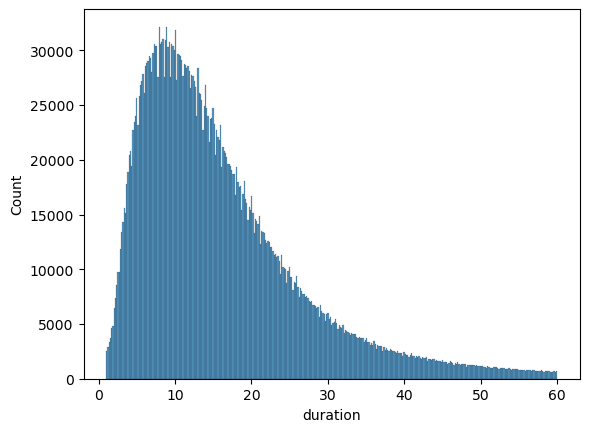

In [48]:
print(df['duration'].describe(percentiles=[.25, .5, .75, .9, .95]))
sns.histplot(df['duration'])

In [26]:
# Feature list
# categorical = ['PULocationID', 'DOLocationID', 'dow', 'pickup_hour']
categorical = ['locationID', 'dow', 'pickup_hour']
numerical = ['trip_distance']
tgt = 'duration'

X_train, X_val, y_train, y_val, dv = complete_preparation(df, categorical, numerical, tgt=tgt)

/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_51168/2610881621.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dow'] = df['tpep_pickup_datetime'].dt.day_name()
/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_51168/2610881621.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_51168/2610881621.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of

30.883360474083503


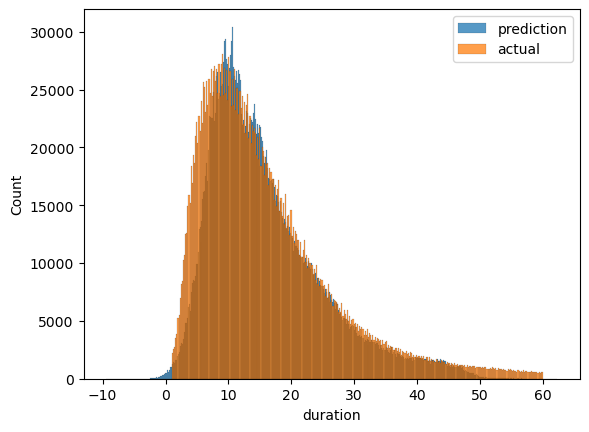

In [34]:
# Prediction
lr = Ridge(alpha=0.01) # LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
print(mean_squared_error(y_train, pred_train))

# Plot
sns.histplot(pred_train, label='prediction')
sns.histplot(y_train, label='actual')
plt.legend()
plt.show()

32.14530345150313


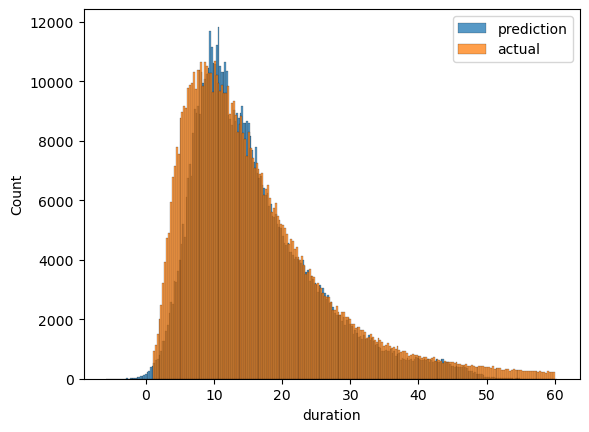

In [35]:
# Check validation data
pred_val = lr.predict(X_val)
print(mean_squared_error(y_val, pred_val))

# Plot
sns.histplot(pred_val, label='prediction')
sns.histplot(y_val, label='actual')
plt.legend()
plt.show()

In [36]:
# Write output model
with open('lin_reg.bin', 'wb') as f:
    pickle.dump((dv, lr), f)